# Comparing Transformer, RNN, and SSM on Synthetic Linear ICL

This notebook:
- Generates synthetic **multi-task linear regression** data.
- Defines three numeric in-context learners:
  - `NumericTransformerICL`
  - `NumericLSTMICL` (RNN)
  - `NumericSSMICL` (SSM-style)
- Optionally **loads checkpoints** `transformer_model.pth`, `rnn_model.pth`, `ssm_model.pth`
  if they are present in the working directory; otherwise trains from scratch.
- Evaluates 0-, 1-, 3-, 5-, and 8-shot ICL performance and plots RMSE vs. k for all 3.


In [1]:
import math
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

print('PyTorch version:', torch.__version__)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

PyTorch version: 2.7.1+cu118
Using device: cuda


In [2]:
@dataclass
class LinearTask:
    xs: np.ndarray   # (K,)
    ys: np.ndarray   # (K,)
    xq: float
    yq: float

def generate_linear_tasks(
    n_tasks: int,
    k_min: int = 4,
    k_max: int = 8,
    x_range = (-10.0, 10.0),
    slope_range = (-3.0, 3.0),
    intercept_range = (-5.0, 5.0),
    noise_std: float = 0.5,
    seed: int = 42,
):
    """Generate a list of multi-shot linear regression tasks.

    Each task has its own slope and intercept:
      y = a x + b + eps, eps ~ N(0, noise_std^2)
    """
    rng = np.random.default_rng(seed)
    tasks = []
    for _ in range(n_tasks):
        a = rng.uniform(*slope_range)
        b = rng.uniform(*intercept_range)
        K = rng.integers(k_min, k_max + 1)

        xs = rng.uniform(*x_range, size=K)
        noise = rng.normal(0.0, noise_std, size=K)
        ys = a * xs + b + noise

        xq = rng.uniform(*x_range)
        yq = a * xq + b + rng.normal(0.0, noise_std)

        tasks.append(LinearTask(xs=xs, ys=ys, xq=float(xq), yq=float(yq)))
    return tasks

N_TRAIN_TASKS = 20000
N_TEST_TASKS  = 4000

train_tasks = generate_linear_tasks(N_TRAIN_TASKS, seed=123)
test_tasks  = generate_linear_tasks(N_TEST_TASKS,  seed=456)

print('Train tasks:', len(train_tasks))
print('Test tasks:', len(test_tasks))

Train tasks: 20000
Test tasks: 4000


In [3]:
class LinearTaskDataset(Dataset):
    def __init__(self, tasks):
        self.tasks = tasks
    def __len__(self):
        return len(self.tasks)
    def __getitem__(self, idx):
        t = self.tasks[idx]
        return (
            torch.tensor(t.xs, dtype=torch.float32),
            torch.tensor(t.ys, dtype=torch.float32),
            torch.tensor(t.xq, dtype=torch.float32),
            torch.tensor(t.yq, dtype=torch.float32),
        )

def build_icl_tokens(pairs, x_query):
    """Demo tokens: [x_i, y_i, 1.0, 0.0], query token: [x_q, 0.0, 0.0, 1.0]."""
    tokens = []
    for x, y in pairs:
        tokens.append([float(x), float(y), 1.0, 0.0])
    tokens.append([float(x_query), 0.0, 0.0, 1.0])
    return torch.tensor(tokens, dtype=torch.float32)

train_dataset = LinearTaskDataset(train_tasks)
test_dataset  = LinearTaskDataset(test_tasks)
print('Train dataset size:', len(train_dataset))
print('Test dataset size:', len(test_dataset))

Train dataset size: 20000
Test dataset size: 4000


In [4]:
def make_collate_fn(k_min=1, k_max=8):
    def collate(batch):
        token_seqs, lengths, ys_out = [], [], []
        for xs, ys, xq, yq in batch:
            xs = xs.numpy(); ys = ys.numpy()
            xq = float(xq.item()); yq = float(yq.item())
            K_total = xs.shape[0]
            if K_total == 0:
                continue
            k_hi = min(k_max, K_total)
            k_lo = min(k_min, k_hi)
            k = random.randint(k_lo, k_hi)
            idxs = random.sample(range(K_total), k)
            pairs = [(xs[i], ys[i]) for i in idxs]
            tokens = build_icl_tokens(pairs, xq)
            token_seqs.append(tokens)
            lengths.append(tokens.size(0))
            ys_out.append(yq)
        B = len(token_seqs)
        if B == 0:
            return torch.empty(0, 1, 4), torch.empty(0, dtype=torch.long), torch.empty(0)
        T_max = max(lengths)
        x_padded = torch.zeros(B, T_max, 4, dtype=torch.float32)
        for i, tok in enumerate(token_seqs):
            T = tok.size(0)
            x_padded[i, :T, :] = tok
        lengths_t = torch.tensor(lengths, dtype=torch.long)
        ys_out_t = torch.tensor(ys_out, dtype=torch.float32)
        return x_padded, lengths_t, ys_out_t
    return collate

BATCH_SIZE = 64
train_collate = make_collate_fn(k_min=1, k_max=8)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=train_collate)
x_dbg, len_dbg, y_dbg = next(iter(train_loader))
print('Batch shapes:', x_dbg.shape, len_dbg.shape, y_dbg.shape)

Batch shapes: torch.Size([64, 9, 4]) torch.Size([64]) torch.Size([64])


In [5]:
class NumericTransformerICL(nn.Module):
    def __init__(
        self,
        input_dim=4,
        d_model=128,
        n_heads=4,
        n_layers=4,
        max_len=16,
        dropout=0.1,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.d_model = d_model
        self.max_len = max_len
        self.value_proj = nn.Linear(input_dim, d_model)
        self.pos_embed  = nn.Embedding(max_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.reg_head = nn.Linear(d_model, 1)
    def forward(self, x, lengths):
        B, T, D_in = x.shape
        device = x.device
        if T > self.max_len:
            raise ValueError(f'T={T} > max_len={self.max_len}')
        h = self.value_proj(x)
        pos_ids = torch.arange(T, device=device)[None, :]
        pos = self.pos_embed(pos_ids)
        h = h + pos
        idxs = torch.arange(T, device=device)[None, :].expand(B, T)
        pad_mask = idxs >= lengths.unsqueeze(1)
        h_enc = self.encoder(h, src_key_padding_mask=pad_mask)
        last_idx = (lengths - 1).clamp(min=0)
        batch_idx = torch.arange(B, device=device)
        h_last = h_enc[batch_idx, last_idx, :]
        y_pred = self.reg_head(h_last).squeeze(-1)
        return y_pred


In [6]:
class NumericLSTMICL(nn.Module):
    def __init__(self, input_dim=4, d_model=128, n_layers=2, dropout=0.1):
        super().__init__()
        self.value_proj = nn.Linear(input_dim, d_model)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=d_model,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.reg_head = nn.Linear(d_model, 1)
    def forward(self, x, lengths):
        # x: (B, T, input_dim)
        B, T, D_in = x.shape
        device = x.device
        h = self.value_proj(x)
        lengths_sorted, idx_sort = torch.sort(lengths, descending=True)
        h_sorted = h[idx_sort]
        packed = nn.utils.rnn.pack_padded_sequence(
            h_sorted, lengths_sorted.cpu(), batch_first=True, enforce_sorted=True
        )
        packed_out, (h_n, c_n) = self.lstm(packed)
        h_last = h_n[-1]  # (B_sorted, d_model)
        _, idx_unsort = torch.sort(idx_sort)
        h_last = h_last[idx_unsort]
        y_pred = self.reg_head(h_last).squeeze(-1)
        return y_pred


In [7]:
class SSMBlock(nn.Module):
    """
    Simplified Mamba-style selective SSM block.
    Uses gating + convolution + state-space recurrence.
    """

    def __init__(self, d_model, d_state=128, expand=2, dt_rank="auto"):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.expand = expand

        inner = d_model * expand

        # Gated MLP (Mamba: S4D-style)
        self.in_proj = nn.Linear(d_model, inner * 2)   # x → (u, v) (gating)
        self.out_proj = nn.Linear(inner, d_model)

        # Convolution part (local mixing)
        self.conv = nn.Conv1d(inner, inner, kernel_size=3, padding=1, groups=inner)

        # State-space parameters (continuous-time)
        self.A = nn.Parameter(torch.randn(inner, d_state) * 0.01)
        self.B = nn.Parameter(torch.randn(inner, d_state) * 0.01)
        self.C = nn.Parameter(torch.randn(inner, d_state) * 0.01)
        self.D = nn.Parameter(torch.zeros(inner))

    def forward(self, x, pad_mask=None):
        """
        x: (B, T, d_model)
        pad_mask: (B, T) with True for padding
        """
        B, T, D = x.shape

        # (B, T, 2*inner) → split into gate + content
        uv = self.in_proj(x)
        u, v = uv.chunk(2, dim=-1)

        # Conv mixing (B, inner, T)
        v_conv = self.conv(v.transpose(1, 2)).transpose(1, 2)

        # Selective SSM recurrence
        # Simple "scan" over time
        h = torch.zeros(B, self.A.size(1), device=x.device)
        hs = []

        # time convolution + gating
        v_mix = v_conv * torch.sigmoid(u)

        for t in range(T):
            if pad_mask is not None and pad_mask[:, t].any():
                # skip padded
                h = h.clone()
            else:
                # continuous-time update (linear recurrence)
                h = h + v_mix[:, t] @ self.A + v_mix[:, t] @ self.B
            hs.append(h @ self.C.T + self.D)

        h_out = torch.stack(hs, dim=1)  # (B, T, inner)
        return self.out_proj(h_out)



class NumericSSMICL(nn.Module):
    def __init__(
        self,
        input_dim=4,
        d_model=128,
        n_layers=4,
        d_state=64,
        dropout=0.1,
    ):
        super().__init__()

        self.value_proj = nn.Linear(input_dim, d_model)
        self.layers = nn.ModuleList(
            [SSMBlock(d_model=d_model, d_state=d_state) for _ in range(n_layers)]
        )
        self.norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(n_layers)])

        self.reg_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1),
        )

    def forward(self, x, lengths):
        """
        x: (B, T, 4)
        lengths: (B,)
        """
        B, T, _ = x.shape
        device = x.device

        h = self.value_proj(x)  # (B, T, d_model)

        # Build padding mask: True = padded
        idxs = torch.arange(T, device=device)[None, :].expand(B, T)
        pad_mask = idxs >= lengths.unsqueeze(1)

        for layer, norm in zip(self.layers, self.norms):
            h = h + layer(h, pad_mask=pad_mask)
            h = norm(h)

        # pick the final non-pad hidden state
        last_idx = (lengths - 1).clamp(min=0)
        batch_idx = torch.arange(B, device=device)
        h_last = h[batch_idx, last_idx, :]

        return self.reg_head(h_last).squeeze(-1)


In [8]:
def train_and_record(model, train_loader, epochs=5, lr=1e-4, device='cuda'):
    """
    Trains the model while recording average training loss per epoch.
    Returns: model, history (list of epoch-average MSE)
    """
    model.to(device)
    crit = nn.MSELoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    for epoch in range(epochs):
        model.train()
        total_mse, total_n = 0.0, 0

        for x, lengths, y in train_loader:
            if x.size(0) == 0:
                continue
            
            x = x.to(device)
            lengths = lengths.to(device)
            y = y.to(device)

            opt.zero_grad()
            preds = model(x, lengths)
            mse = crit(preds, y)
            mse.backward()
            opt.step()

            B = x.size(0)
            total_mse += mse.item() * B
            total_n += B

        avg_mse = total_mse / max(total_n, 1)
        history.append(avg_mse)
        print(f"Epoch {epoch+1}/{epochs} — MSE={avg_mse:.4f}, RMSE={avg_mse**0.5:.4f}")

    return model, history

In [9]:
def load_or_train(model, ckpt_path, train_loader, epochs=5, lr=1e-4, device='cuda'):
    """
    Load a checkpoint if it exists; otherwise train and save.

    NOTE: We set weights_only=False explicitly because PyTorch 2.6+
    defaults to weights_only=True, which breaks loading older checkpoints
    or ones that saved full model objects.
    """
    if os.path.exists(ckpt_path):
        print(f'Loading checkpoint from {ckpt_path}')
        # We trust these checkpoints (they were created by us), so weights_only=False is fine.
        state = torch.load(ckpt_path, map_location=device, weights_only=False)

        # Handle both state_dict-only and full-model checkpoints
        if isinstance(state, dict) and 'model_state_dict' in state:
            model.load_state_dict(state['model_state_dict'])
        elif isinstance(state, dict):
            # assume it's already a pure state_dict
            model.load_state_dict(state)
        else:
            # assume the checkpoint IS the model object
            model = state

        model.to(device)
        return model
    else:
        print(f'Checkpoint {ckpt_path} not found – training from scratch')
        model, hist = train_and_record(model, train_loader, epochs=epochs, lr=lr, device=device)
        torch.save(model.state_dict(), ckpt_path)
        print(f'Saved checkpoint to {ckpt_path}')
        return model, hist


In [10]:
K_MAX_TOKENS = 8 + 1
transformer = NumericTransformerICL(input_dim=4, d_model=128, n_heads=4, n_layers=4, max_len=K_MAX_TOKENS+2, dropout=0.1)
rnn_model   = NumericLSTMICL(input_dim=4, d_model=128, n_layers=4, dropout=0.1)
ssm_model   = NumericSSMICL(input_dim=4, d_model=128, n_layers=4, dropout=0.1)

print('Transformer params:', sum(p.numel() for p in transformer.parameters()))
print('RNN params:', sum(p.numel() for p in rnn_model.parameters()))
print('SSM params:', sum(p.numel() for p in ssm_model.parameters()))

EPOCHS = 5
LR = 3e-4

transformer, hist_transformer = load_or_train(transformer, 'transformer_model.pth', train_loader, epochs=EPOCHS, lr=LR, device=device)
rnn_model, hist_lstm   = load_or_train(rnn_model,   'rnn_model.pth',         train_loader, epochs=EPOCHS, lr=LR, device=device)
ssm_model, hist_ssm   = load_or_train(ssm_model,   'ssm_model.pth',         train_loader, epochs=EPOCHS, lr=LR, device=device)


Transformer params: 795265
RNN params: 529153
SSM params: 615809
Checkpoint transformer_model.pth not found – training from scratch
Epoch 1/5 — MSE=33.8270, RMSE=5.8161
Epoch 2/5 — MSE=16.1136, RMSE=4.0142
Epoch 3/5 — MSE=12.8527, RMSE=3.5851
Epoch 4/5 — MSE=11.8689, RMSE=3.4451
Epoch 5/5 — MSE=11.3271, RMSE=3.3656
Saved checkpoint to transformer_model.pth
Checkpoint rnn_model.pth not found – training from scratch
Epoch 1/5 — MSE=70.7720, RMSE=8.4126
Epoch 2/5 — MSE=15.5162, RMSE=3.9391
Epoch 3/5 — MSE=12.1123, RMSE=3.4803
Epoch 4/5 — MSE=10.6796, RMSE=3.2680
Epoch 5/5 — MSE=10.3750, RMSE=3.2210
Saved checkpoint to rnn_model.pth
Checkpoint ssm_model.pth not found – training from scratch
Epoch 1/5 — MSE=53.2913, RMSE=7.3001
Epoch 2/5 — MSE=21.2397, RMSE=4.6087
Epoch 3/5 — MSE=17.4594, RMSE=4.1784
Epoch 4/5 — MSE=15.2437, RMSE=3.9043
Epoch 5/5 — MSE=14.2587, RMSE=3.7761
Saved checkpoint to ssm_model.pth


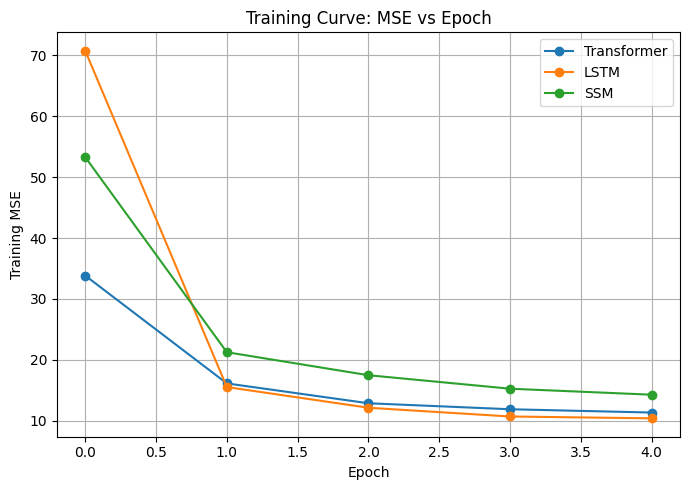

In [11]:
plt.figure(figsize=(7,5))
plt.plot(hist_transformer, label="Transformer", marker='o')
plt.plot(hist_lstm,        label="LSTM",        marker='o')
plt.plot(hist_ssm,         label="SSM",         marker='o')

plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Training Curve: MSE vs Epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
def run_icl_eval(model, tasks, k_list=(0,1,3,5,8), num_samples=1000, device='cuda'):
    model.to(device)
    model.eval()
    results = {}
    with torch.no_grad():
        for k in k_list:
            sq_errors, used = [], 0
            for _ in range(num_samples):
                t = random.choice(tasks)
                xs, ys, xq, yq = t.xs, t.ys, t.xq, t.yq
                K_total = xs.shape[0]
                if k > K_total:
                    continue
                if k == 0:
                    pairs = []
                else:
                    idxs = random.sample(range(K_total), k)
                    pairs = [(xs[i], ys[i]) for i in idxs]
                tokens = build_icl_tokens(pairs, xq)
                length = torch.tensor([tokens.size(0)], dtype=torch.long).to(device)
                x = tokens.unsqueeze(0).to(device)
                y_pred = model(x, length).item()
                sq_errors.append((y_pred - yq)**2)
                used += 1
            if used == 0:
                results[k] = float('nan')
                print(f'k={k}: no valid tasks')
            else:
                mse = sum(sq_errors)/used
                rmse = mse**0.5
                results[k] = rmse
                print(f'k={k}-shot: RMSE={rmse:.4f} over {used} tasks')
    return results


In [13]:
k_list = [0,1,3,5,8]
num_samples = 1000

all_results = {}
for name, model in [('SSM', ssm_model), ('Transformer', transformer), ('LSTM', rnn_model)]:
    print(f"\n=== Evaluating {name} ===")
    all_results[name] = run_icl_eval(model, test_tasks, k_list=k_list, num_samples=num_samples, device=device)

print('\nAll RMSE results:')
for name, res in all_results.items():
    print(name, res)


=== Evaluating SSM ===
k=0-shot: RMSE=11.2900 over 1000 tasks
k=1-shot: RMSE=6.2080 over 1000 tasks
k=3-shot: RMSE=9.1373 over 1000 tasks
k=5-shot: RMSE=10.9419 over 810 tasks
k=8-shot: RMSE=10.3317 over 202 tasks

=== Evaluating Transformer ===


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


k=0-shot: RMSE=10.2872 over 1000 tasks
k=1-shot: RMSE=5.6560 over 1000 tasks
k=3-shot: RMSE=2.2856 over 1000 tasks
k=5-shot: RMSE=1.8795 over 790 tasks
k=8-shot: RMSE=1.9588 over 193 tasks

=== Evaluating LSTM ===
k=0-shot: RMSE=9.8716 over 1000 tasks
k=1-shot: RMSE=5.0309 over 1000 tasks
k=3-shot: RMSE=2.0142 over 1000 tasks
k=5-shot: RMSE=1.4104 over 813 tasks
k=8-shot: RMSE=1.2829 over 199 tasks

All RMSE results:
SSM {0: 11.28996156769333, 1: 6.208046863035499, 3: 9.137273032513006, 5: 10.94187815510774, 8: 10.331651960071424}
Transformer {0: 10.28716761984929, 1: 5.656014229720232, 3: 2.2856101818526438, 5: 1.8794912358480675, 8: 1.9587801591059164}
LSTM {0: 9.871598990128357, 1: 5.030856099604425, 3: 2.014168322412829, 5: 1.4104144927755702, 8: 1.2828671502980398}


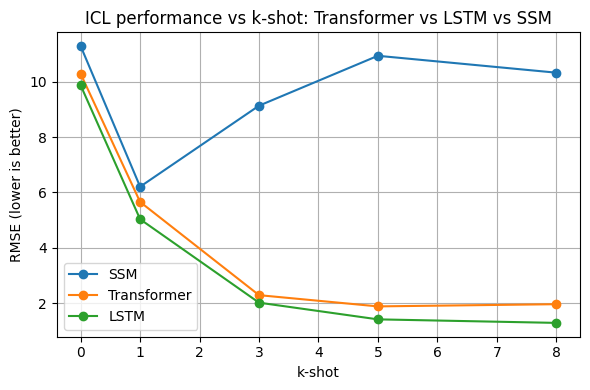

In [14]:
plt.figure(figsize=(6,4))
for name, res in all_results.items():
    ks = sorted(res.keys())
    rmses = [res[k] for k in ks]
    plt.plot(ks, rmses, marker='o', label=name)
plt.xlabel('k-shot')
plt.ylabel('RMSE (lower is better)')
plt.title('ICL performance vs k-shot: Transformer vs LSTM vs SSM')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()